In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving test_zomato.csv to test_zomato.csv


In [3]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File:", file_name)

Dataset loaded successfully!
File: test_zomato.csv


In [4]:
df.head()

,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 9552
Number of columns: 22
Shape: (9552, 22)


In [6]:
print("Column Names:")
for col in df.columns:
    print(col)

Column Names:
Unnamed: 0
Restaurant ID
Restaurant Name
Country Code
City
Address
Locality
Locality Verbose
Longitude
Latitude
Cuisines
Average Cost for two
Currency
Has Table booking
Has Online delivery
Is delivering now
Switch to order menu
Price range
Aggregate rating
Rating color
Rating text
Votes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9552 entries, 0 to 9551
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            9552 non-null   object 
 1   Restaurant ID         9552 non-null   object 
 2   Restaurant Name       9552 non-null   object 
 3   Country Code          9552 non-null   float64
 4   City                  9552 non-null   object 
 5   Address               9552 non-null   object 
 6   Locality              9551 non-null   object 
 7   Locality Verbose      9551 non-null   object 
 8   Longitude             9551 non-null   object 
 9   Latitude              9551 non-null   object 
 10  Cuisines              9542 non-null   object 
 11  Average Cost for two  9551 non-null   object 
 12  Currency              9551 non-null   object 
 13  Has Table booking     9551 non-null   object 
 14  Has Online delivery   9551 non-null   object 
 15  Is delivering now    

In [8]:
df.dtypes

,0
Unnamed: 0,object
Restaurant ID,object
Restaurant Name,object
Country Code,float64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,object
Latitude,object


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0               0
Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 1
Locality Verbose         1
Longitude                1
Latitude                 1
Cuisines                10
Average Cost for two     1
Currency                 1
Has Table booking        1
Has Online delivery      1
Is delivering now        1
Switch to order menu     1
Price range              2
Aggregate rating         2
Rating color             2
Rating text              2
Votes                    2
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_analysis = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_analysis = missing_analysis.sort_values(
    by="Missing Values",
    ascending=False
)

missing_analysis

,Missing Values,Missing Percentage
Cuisines,10,0.104690
Price range,2,0.020938
Votes,2,0.020938
Rating text,2,0.020938
Rating color,2,0.020938
Aggregate rating,2,0.020938
Has Table booking,1,0.010469
Currency,1,0.010469
Average Cost for two,1,0.010469
Latitude,1,0.010469


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [12]:
duplicates = df[df.duplicated()]

duplicates

,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes


In [13]:
print("Before conversion:")
print(df["Average Cost for two"].dtype)

Before conversion:
object


In [14]:
df["Average Cost for two"] = (
    df["Average Cost for two"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Average Cost for two"] = pd.to_numeric(
    df["Average Cost for two"],
    errors="coerce"
)

print("After conversion:")
print(df["Average Cost for two"].dtype)

After conversion:
float64


In [15]:
print(df.dtypes)

Unnamed: 0               object
Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two    float64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range             float64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                   float64
dtype: object


In [16]:
df.describe()

,Country Code,Average Cost for two,Price range,Aggregate rating,Votes
count,9552.000000,9550.000000,9550.000000,9550.000000,9550.000000
mean,18.374564,1199.326387,1.804607,2.666314,156.923037
std,56.754313,16122.023220,0.905378,1.516447,430.189709
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,250.000000,1.000000,2.500000,5.000000
50%,1.000000,400.000000,2.000000,3.200000,31.000000
75%,1.000000,700.000000,2.000000,3.700000,131.000000
max,216.000000,800000.000000,4.000000,4.900000,10934.000000


In [17]:
df.describe(include="object")

,Unnamed: 0,Restaurant ID,Restaurant Name,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Rating color,Rating text
count,9552,9552,9552,9552,9552,9551,9551,9551,9551,9542,9551,9551,9551,9551,9551,9550,9550
unique,9552,9552,7447,142,8919,1208,1265,8120,8677,1826,13,3,3,3,2,6,6
top,9534,6004089,Cafe Coffee Day,New Delhi,"Dilli Haat, INA, New Delhi",Connaught Place,"Connaught Place, New Delhi",0.0,0.0,North Indian,Indian Rupees(Rs.),No,No,No,No,Orange,Average
freq,1,1,83,5473,11,122,122,498,498,936,8652,8392,7099,9516,9550,3736,3736


In [18]:
print("Has Table booking:")
print(df["Has Table booking"].value_counts(dropna=False))

print("\nHas Online delivery:")
print(df["Has Online delivery"].value_counts(dropna=False))

print("\nPrice range:")
print(df["Price range"].value_counts(dropna=False))

print("\nRating text:")
print(df["Rating text"].value_counts(dropna=False))

Has Table booking:
Has Table booking
No     8392
Yes    1158
NaN       1
3.2       1
Name: count, dtype: int64

Has Online delivery:
Has Online delivery
No        7099
Yes       2451
NaN          1
Orange       1
Name: count, dtype: int64

Price range:
Price range
1.0    4444
2.0    3113
3.0    1408
4.0     585
NaN       2
Name: count, dtype: int64

Rating text:
Rating text
Average      3736
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
NaN             2
Name: count, dtype: int64


In [19]:
unique_cities = df["City"].nunique()

print("Number of unique cities:", unique_cities)

Number of unique cities: 142


In [20]:
city_counts = df["City"].value_counts()

print("City with the highest number of restaurants:")
print(city_counts.head(1))

City with the highest number of restaurants:
City
New Delhi    5473
Name: count, dtype: int64


In [21]:
print("Top 10 cities by number of restaurants:")
print(city_counts.head(10))

Top 10 cities by number of restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


In [22]:
cuisine_counts = df["Cuisines"].value_counts()

print("Most frequently appearing cuisine:")
print(cuisine_counts.head(1))

Most frequently appearing cuisine:
Cuisines
North Indian    936
Name: count, dtype: int64


In [23]:
print("Top 10 most common cuisines:")
print(cuisine_counts.head(10))

Top 10 most common cuisines:
Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [24]:
average_rating = df["Aggregate rating"].mean()

print("Average restaurant rating:", round(average_rating, 2))

Average restaurant rating: 2.67


In [25]:
highest_votes = df["Votes"].max()

print("Highest number of votes:", highest_votes)

Highest number of votes: 10934.0


In [26]:
highest_votes_restaurant = df.loc[
    df["Votes"].idxmax()
]

print("Restaurant Name:", highest_votes_restaurant["Restaurant Name"])
print("City:", highest_votes_restaurant["City"])
print("Votes:", highest_votes_restaurant["Votes"])
print("Aggregate Rating:", highest_votes_restaurant["Aggregate rating"])

Restaurant Name: Toit
City: Bangalore
Votes: 10934.0
Aggregate Rating: 4.8


In [27]:
average_cost = df["Average Cost for two"].mean()

print("Average cost for two:", round(average_cost, 2))

Average cost for two: 1199.33


In [28]:
online_delivery_rating = df.groupby(
    "Has Online delivery"
)["Aggregate rating"].mean()

print("Average rating by online delivery:")
print(online_delivery_rating)

Average rating by online delivery:
Has Online delivery
No        2.465192
Orange         NaN
Yes       3.248837
Name: Aggregate rating, dtype: float64


In [29]:
online_yes = df[
    df["Has Online delivery"] == "Yes"
]["Aggregate rating"].mean()

online_no = df[
    df["Has Online delivery"] == "No"
]["Aggregate rating"].mean()

print("Average rating with Online Delivery:", round(online_yes, 2))
print("Average rating without Online Delivery:", round(online_no, 2))

Average rating with Online Delivery: 3.25
Average rating without Online Delivery: 2.47


In [30]:
if online_yes > online_no:
    print("Restaurants with Online Delivery generally have higher ratings.")
elif online_yes < online_no:
    print("Restaurants without Online Delivery generally have higher ratings.")
else:
    print("Both groups have the same average rating.")

Restaurants with Online Delivery generally have higher ratings.


In [31]:
table_booking_rating = df.groupby(
    "Has Table booking"
)["Aggregate rating"].mean()

print("Average rating by table booking:")
print(table_booking_rating)

Average rating by table booking:
Has Table booking
3.2         NaN
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64


In [32]:
table_yes = df[
    df["Has Table booking"] == "Yes"
]["Aggregate rating"].mean()

table_no = df[
    df["Has Table booking"] == "No"
]["Aggregate rating"].mean()

print("Average rating with Table Booking:", round(table_yes, 2))
print("Average rating without Table Booking:", round(table_no, 2))

Average rating with Table Booking: 3.44
Average rating without Table Booking: 2.56


In [33]:
if table_yes > table_no:
    print("Restaurants with Table Booking generally have higher ratings.")
elif table_yes < table_no:
    print("Restaurants without Table Booking generally have higher ratings.")
else:
    print("Both groups have the same average rating.")

Restaurants with Table Booking generally have higher ratings.


In [34]:
top_10_cities = df["City"].value_counts().head(10)

print(top_10_cities)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


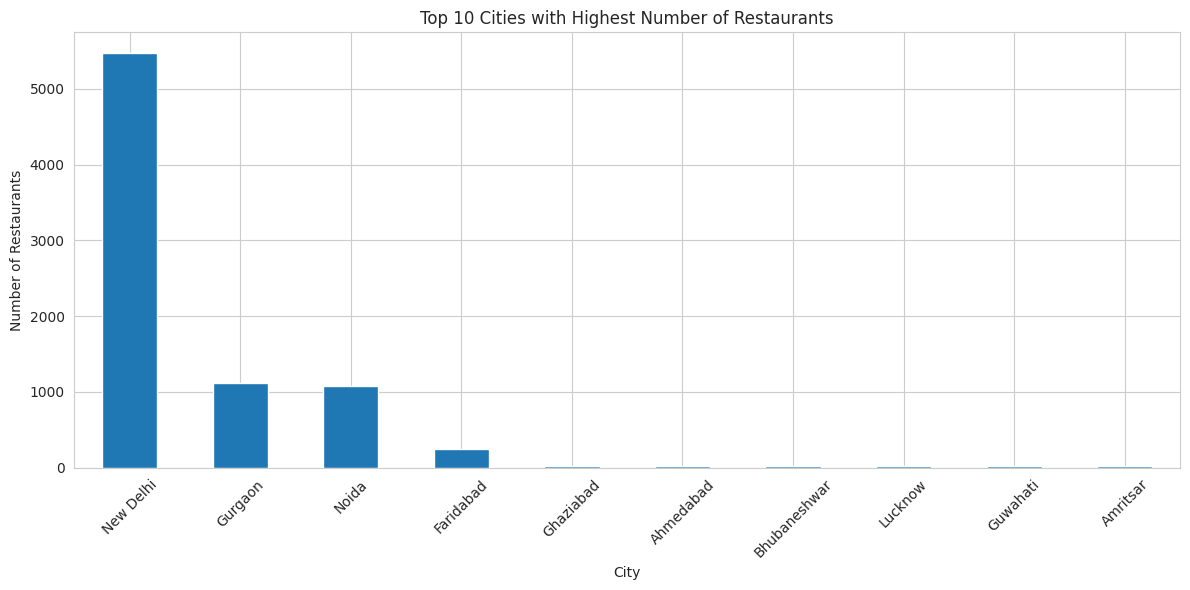

In [35]:
plt.figure(figsize=(12, 6))

top_10_cities.plot(kind="bar")

plt.title("Top 10 Cities with Highest Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
print("""
Interpretation:

The bar chart shows the top 10 cities based on the number
of restaurants listed in the dataset.

The city with the highest bar has the highest restaurant presence.
""")


Interpretation:

The bar chart shows the top 10 cities based on the number
of restaurants listed in the dataset.

The city with the highest bar has the highest restaurant presence.



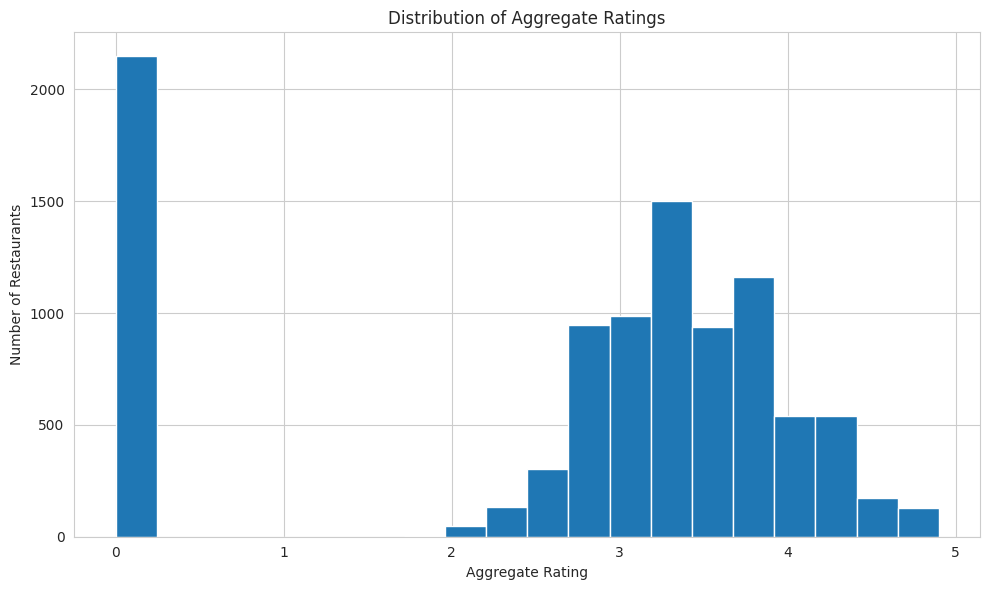

In [37]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Aggregate rating"].dropna(),
    bins=20
)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

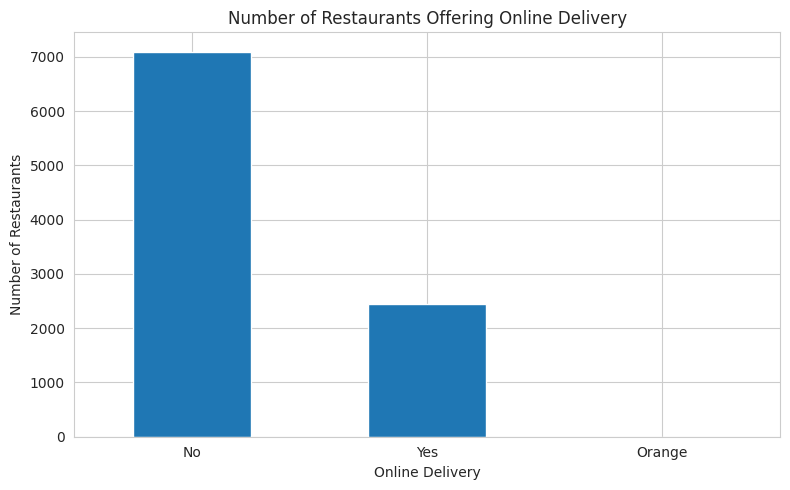

In [38]:
delivery_counts = df["Has Online delivery"].value_counts()

plt.figure(figsize=(8, 5))

delivery_counts.plot(kind="bar")

plt.title("Number of Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
print("""
Interpretation:

The bar chart compares restaurants that offer online delivery
with restaurants that do not offer online delivery.

It shows which category contains more restaurants.
""")


Interpretation:

The bar chart compares restaurants that offer online delivery
with restaurants that do not offer online delivery.

It shows which category contains more restaurants.



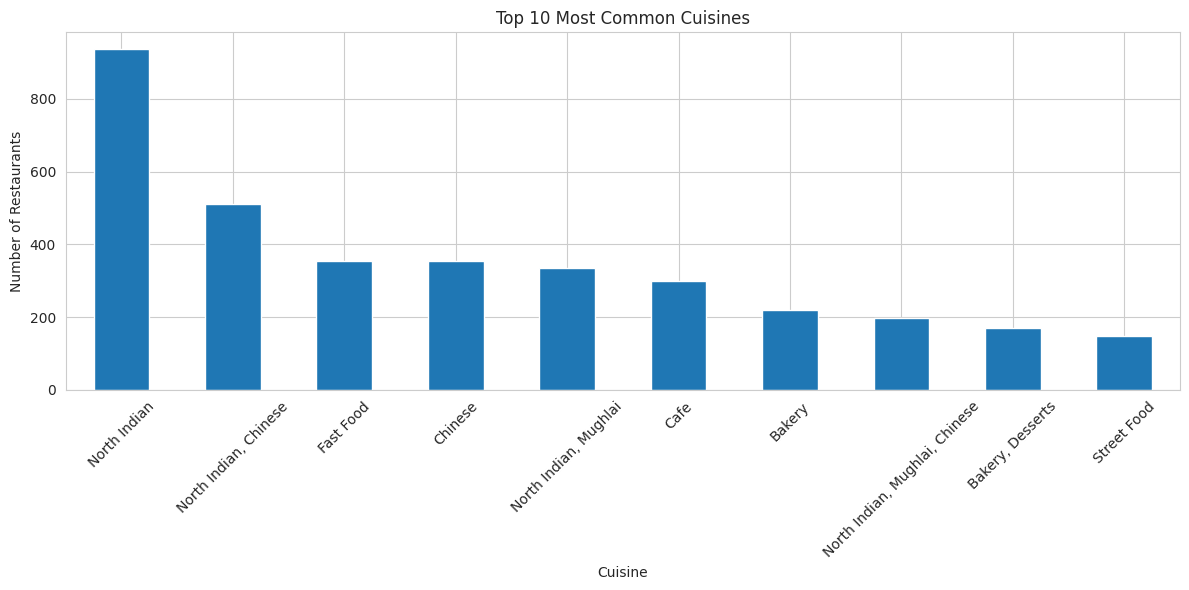

In [40]:
top_10_cuisines = df["Cuisines"].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_10_cuisines.plot(kind="bar")

plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
average_rating_price = df.groupby(
    "Price range"
)["Aggregate rating"].mean()

print(average_rating_price)

Price range
1.0    1.999887
2.0    2.941054
3.0    3.683381
4.0    3.818974
Name: Aggregate rating, dtype: float64


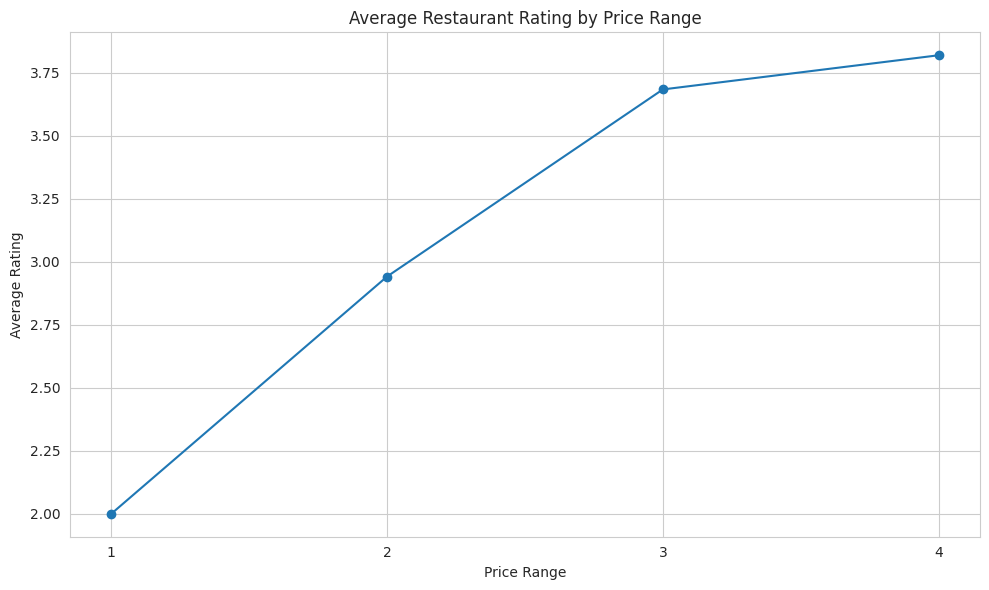

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    average_rating_price.index,
    average_rating_price.values,
    marker="o"
)

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.xticks(average_rating_price.index)

plt.tight_layout()
plt.show()

In [43]:
# 1. City with highest restaurant presence
highest_city = df["City"].value_counts().idxmax()
highest_city_count = df["City"].value_counts().max()

# 2. Most popular cuisine
most_popular_cuisine = df["Cuisines"].value_counts().idxmax()

# 3. Online delivery ratings
online_delivery_yes = df[
    df["Has Online delivery"] == "Yes"
]["Aggregate rating"].mean()

online_delivery_no = df[
    df["Has Online delivery"] == "No"
]["Aggregate rating"].mean()

# 4. Table booking ratings
table_booking_yes = df[
    df["Has Table booking"] == "Yes"
]["Aggregate rating"].mean()

table_booking_no = df[
    df["Has Table booking"] == "No"
]["Aggregate rating"].mean()


print("=" * 60)
print("FINAL INSIGHTS")
print("=" * 60)

print("\n1. Which city has the highest restaurant presence?")
print(f"   {highest_city}")
print(f"   Number of restaurants: {highest_city_count}")

print("\n2. What is the most popular cuisine?")
print(f"   {most_popular_cuisine}")

print("\n3. Do restaurants with Online Delivery generally have higher ratings?")
print(f"   With Online Delivery: {online_delivery_yes:.2f}")
print(f"   Without Online Delivery: {online_delivery_no:.2f}")

if online_delivery_yes > online_delivery_no:
    print("   Answer: Yes")
else:
    print("   Answer: No")

print("\n4. Do restaurants offering Table Booking receive better ratings?")
print(f"   With Table Booking: {table_booking_yes:.2f}")
print(f"   Without Table Booking: {table_booking_no:.2f}")

if table_booking_yes > table_booking_no:
    print("   Answer: Yes")
else:
    print("   Answer: No")

FINAL INSIGHTS

1. Which city has the highest restaurant presence?
   New Delhi
   Number of restaurants: 5473

2. What is the most popular cuisine?
   North Indian

3. Do restaurants with Online Delivery generally have higher ratings?
   With Online Delivery: 3.25
   Without Online Delivery: 2.47
   Answer: Yes

4. Do restaurants offering Table Booking receive better ratings?
   With Table Booking: 3.44
   Without Table Booking: 2.56
   Answer: Yes


In [44]:
print("=" * 60)
print("KEY OBSERVATIONS")
print("=" * 60)

print(f"""
1. The city with the highest restaurant presence is {highest_city},
   with {highest_city_count} restaurants.

2. The most frequently appearing cuisine is
   {most_popular_cuisine}.

3. The overall average restaurant rating is
   {average_rating:.2f}.

4. The average cost for two people is
   {average_cost:.2f}.

5. The average rating for restaurants with online delivery is
   {online_delivery_yes:.2f}, while restaurants without online
   delivery have an average rating of {online_delivery_no:.2f}.

6. Restaurants with table booking have an average rating of
   {table_booking_yes:.2f}, while restaurants without table
   booking have an average rating of {table_booking_no:.2f}.
""")

KEY OBSERVATIONS

1. The city with the highest restaurant presence is New Delhi,
   with 5473 restaurants.

2. The most frequently appearing cuisine is
   North Indian.

3. The overall average restaurant rating is
   2.67.

4. The average cost for two people is
   1199.33.

5. The average rating for restaurants with online delivery is
   3.25, while restaurants without online
   delivery have an average rating of 2.47.

6. Restaurants with table booking have an average rating of
   3.44, while restaurants without table
   booking have an average rating of 2.56.



In [45]:
print("Final dataset shape:", df.shape)

print("\nFinal data types:")
print(df.dtypes)

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

Final dataset shape: (9552, 22)

Final data types:
Unnamed: 0               object
Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two    float64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range             float64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                   float64
dtype: object

Remaining missing values:
Unnamed: 0               0
Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 1
Locality Verbos